In [1]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `research.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# NER Results Analysis — decicontas.br

This notebook loads all checkpoint DataFrames, computes token-level and span-level metrics, and provides comparative insights across models and strategies.

In [2]:
import os
import pickle
import warnings
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict
from rapidfuzz import fuzz
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Metric Functions

In [3]:
from collections import defaultdict

import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

from research.ner_metrics import (
    DICT_LABELS,
    convert_pred_to_golden_format,
    _strip_bio,
    compute_iou_score,
    calculate_metrics,
)


def evaluate_results(df_results):
    """Compat wrapper: returns (flat_metrics, raw) as ner_results.ipynb expects."""
    from research.ner_metrics import evaluate_results as _eval
    return _eval(df_results, return_raw=True)


print('Metric functions loaded.')


Metric functions loaded.


## 2. Load Checkpoints & Compute Metrics

In [4]:

CHECKPOINTS_DIR = Path('dataset/results/checkpoints/')

all_results = {}
all_raw = {}

pkl_files = sorted(CHECKPOINTS_DIR.glob('*.pkl'))
print(f'Found {len(pkl_files)} checkpoints:\n')
for f in pkl_files:
    print(f'  {f.name}')


Found 30 checkpoints:

  bilstm-crf__supervised.pkl
  deepseek-v3__cot.pkl
  deepseek-v3__few_shot.pkl
  deepseek-v3__self_refinement.pkl
  deepseek-v3__two_stage.pkl
  gemini-2-5-flash__cot.pkl
  gemini-2-5-flash__dynamic_few_shot.pkl
  gemini-2-5-flash__few_shot.pkl
  gemini-2-5-flash__self_refinement.pkl
  gemini-2-5-flash__two_stage.pkl
  gemini-2-5-pro__few_shot.pkl
  gpt-35-turbo__few_shot.pkl
  gpt-4o__few_shot.pkl
  gpt-5-4-mini__cot.pkl
  gpt-5-4-mini__dynamic_few_shot.pkl
  gpt-5-4-mini__few_shot.pkl
  gpt-5-4-mini__self_refinement.pkl
  gpt-5-4-mini__two_stage.pkl
  gpt-5-4-nano__cot.pkl
  gpt-5-4-nano__dynamic_few_shot.pkl
  gpt-5-4-nano__few_shot.pkl
  gpt-5-4-nano__self_refinement.pkl
  gpt-5-4-nano__two_stage.pkl
  llama-4-maverick__few_shot.pkl
  mistral-small-3-2__dynamic_few_shot.pkl
  mistral-small-3-2__few_shot.pkl
  neuralmind_bert-base-portuguese-cased__supervised.pkl
  neuralmind_bert-large-portuguese-cased__supervised.pkl
  qwen3-235b__few_shot.pkl
  rufimelo_Le

In [5]:
def is_bio_format(df):
    """Detect if a DataFrame stores BIO tags directly (supervised format).
    These have numeric columns and cells containing BIO tags like 'O', 'B-MULTA', etc."""
    if 'text' in df.columns or 'pred' in df.columns:
        return False
    # Check first non-NaN value in column 0
    if 0 in df.columns:
        sample = df[0].dropna().iloc[0] if len(df[0].dropna()) > 0 else None
        if isinstance(sample, str) and (sample == 'O' or sample.startswith('B-') or sample.startswith('I-')):
            return True
    return False

def evaluate_bio_format(df_pred, df_gold):
    """Compute token-level and span-level metrics for BIO-format DataFrames.
    Both DataFrames have rows=documents, columns=token indices, values=BIO tags."""
    assert len(df_pred) == len(df_gold), f'Row count mismatch: pred={len(df_pred)} gold={len(df_gold)}'
    
    flat_true, flat_pred = [], []
    label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})
    
    for i in range(len(df_pred)):
        pred_row = df_pred.iloc[i].dropna().tolist()
        gold_row = df_gold.iloc[i].dropna().tolist()
        
        # Align to shortest length
        min_len = min(len(pred_row), len(gold_row))
        pred_tags = [str(t) for t in pred_row[:min_len]]
        gold_tags = [str(t) for t in gold_row[:min_len]]
        
        # Token-level (strip BIO prefix)
        for t, p in zip(gold_tags, pred_tags):
            tl = _strip_bio(t)
            pl = _strip_bio(p)
            if tl != 'O' or pl != 'O':
                flat_true.append(tl)
                flat_pred.append(pl)
        
        # Extract spans from BIO sequences for IoU
        def extract_spans(tags):
            spans = []
            start, label = None, None
            for j, tag in enumerate(tags):
                if tag.startswith('B-'):
                    if start is not None:
                        spans.append((start, j, label))
                    label = tag[2:]
                    start = j
                elif tag.startswith('I-') and start is not None and tag[2:] == label:
                    continue
                else:
                    if start is not None:
                        spans.append((start, j, label))
                        start, label = None, None
            if start is not None:
                spans.append((start, len(tags), label))
            return spans
        
        gold_spans = extract_spans(gold_tags)
        pred_spans = extract_spans(pred_tags)
        
        for _, _, lab in gold_spans: label_metrics[lab]['total_gold'] += 1
        for _, _, lab in pred_spans: label_metrics[lab]['total_pred'] += 1
        
        matched_pairs = set()
        for pi, p in enumerate(pred_spans):
            for gi, g in enumerate(gold_spans):
                if (pi, gi) in matched_pairs: continue
                if compute_iou_score((p[0], p[1]), (g[0], g[1]), p[2], g[2], threshold=0.5) > 0:
                    label_metrics[p[2]]['matched'] += 1
                    matched_pairs.add((pi, gi))
                    break
    
    # Token metrics
    if not flat_true:
        token_prec = token_rec = token_f1 = 0.0
    else:
        labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
        token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
            flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)
    
    # Span metrics
    total_gold = sum(v['total_gold'] for v in label_metrics.values())
    total_pred = sum(v['total_pred'] for v in label_metrics.values())
    total_matched = sum(v['matched'] for v in label_metrics.values())
    iou_prec = total_matched / total_pred if total_pred > 0 else 0.0
    iou_rec = total_matched / total_gold if total_gold > 0 else 0.0
    iou_f1 = (2 * iou_prec * iou_rec / (iou_prec + iou_rec)) if (iou_prec + iou_rec) > 0 else 0.0
    
    metrics = {
        'token_precision': float(token_prec), 'token_recall': float(token_rec), 'token_f1': float(token_f1),
        'span_precision': iou_prec, 'span_recall': iou_rec, 'span_f1': iou_f1,
    }
    for label, m in label_metrics.items():
        prec = m['matched'] / m['total_pred'] if m['total_pred'] > 0 else 0.0
        rec = m['matched'] / m['total_gold'] if m['total_gold'] > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        metrics[f'f1_{label}'] = f1
        metrics[f'precision_{label}'] = prec
        metrics[f'recall_{label}'] = rec
    return metrics


# --- Load all checkpoints and detect formats ---
bio_checkpoints = {}   # name -> {'true_labels': [...], 'pred_labels': [...]}
llm_checkpoints = {}   # name -> DataFrame (text/pred/golden format)

for pkl_path in pkl_files:
    name = pkl_path.stem
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    # Dict with true_labels/pred_labels (supervised models)
    if isinstance(data, dict) and 'true_labels' in data and 'pred_labels' in data:
        bio_checkpoints[name] = data
        print(f'  {name}: BIO dict ({len(data["pred_labels"])} docs)')
        continue
    
    if isinstance(data, pd.DataFrame):
        df = data
    elif isinstance(data, list):
        df = pd.DataFrame(data)
    else:
        print(f'  {name}: unsupported format {type(data)}, skipping')
        continue
    
    llm_checkpoints[name] = df
    print(f'  {name}: LLM format ({len(df)} rows)')

print(f'\nDetected {len(llm_checkpoints)} LLM checkpoints, {len(bio_checkpoints)} BIO checkpoints.')

# ---- Drop leaked few-shot examples from every checkpoint ----
# 5 dataset ids are present in tools/fewshot.py as exemplos in the prompt,
# leaking gold information at inference time. We exclude them at the same
# row positions across every checkpoint (verified positional alignment).
from research.fewshot import FEWSHOT_RESULT_POSITIONS

for _name, _df in list(llm_checkpoints.items()):
    llm_checkpoints[_name] = _df.drop(index=FEWSHOT_RESULT_POSITIONS, errors="ignore").reset_index(drop=True)

for _name, _data in list(bio_checkpoints.items()):
    keep = [i for i in range(len(_data["true_labels"])) if i not in set(FEWSHOT_RESULT_POSITIONS)]
    bio_checkpoints[_name] = {
        "true_labels": [_data["true_labels"][i] for i in keep],
        "pred_labels": [_data["pred_labels"][i] for i in keep],
        **{k: v for k, v in _data.items() if k not in ("true_labels", "pred_labels")},
    }

print(f"\nFiltered out positions {FEWSHOT_RESULT_POSITIONS} from all checkpoints.")


  bilstm-crf__supervised: BIO dict (866 docs)
  deepseek-v3__cot: LLM format (866 rows)
  deepseek-v3__few_shot: LLM format (866 rows)
  deepseek-v3__self_refinement: LLM format (866 rows)
  deepseek-v3__two_stage: LLM format (866 rows)
  gemini-2-5-flash__cot: LLM format (866 rows)
  gemini-2-5-flash__dynamic_few_shot: LLM format (866 rows)
  gemini-2-5-flash__few_shot: LLM format (866 rows)
  gemini-2-5-flash__self_refinement: LLM format (866 rows)
  gemini-2-5-flash__two_stage: LLM format (866 rows)
  gemini-2-5-pro__few_shot: LLM format (866 rows)
  gpt-35-turbo__few_shot: LLM format (866 rows)
  gpt-4o__few_shot: LLM format (866 rows)
  gpt-5-4-mini__cot: LLM format (866 rows)
  gpt-5-4-mini__dynamic_few_shot: LLM format (866 rows)
  gpt-5-4-mini__few_shot: LLM format (866 rows)
  gpt-5-4-mini__self_refinement: LLM format (866 rows)
  gpt-5-4-mini__two_stage: LLM format (866 rows)
  gpt-5-4-nano__cot: LLM format (866 rows)
  gpt-5-4-nano__dynamic_few_shot: LLM format (866 rows)
  

In [6]:
# --- Process LLM checkpoints ---
"""
print('=== LLM checkpoints ===')

for name, df in llm_checkpoints.items():
    print(f'  {name} ... ', end='')
    try:
        metrics, raw = evaluate_results(df.copy())
        all_results[name] = metrics
        all_raw[name] = raw
        print(f'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}')
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nEvaluated {len(all_results)} LLM checkpoints.')
"""

'\nprint(\'=== LLM checkpoints ===\')\n\nfor name, df in llm_checkpoints.items():\n    print(f\'  {name} ... \', end=\'\')\n    try:\n        metrics, raw = evaluate_results(df.copy())\n        all_results[name] = metrics\n        all_raw[name] = raw\n        print(f\'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}\')\n    except Exception as e:\n        print(f\'ERROR: {e}\')\n\nprint(f\'\nEvaluated {len(all_results)} LLM checkpoints.\')\n'

In [7]:
#model_name = 'gpt-5.4-mini_few_shot'
#json_file = JSON_RESULTS_DIR / f'models_results_decicontas_{model_name}.json'
#df_results = pd.read_json(json_file)
#metrics, raw = evaluate_results(df_results)
#metrics

In [8]:
# --- Load additional LLM results from JSON files ---
# These are results from models evaluated in a separate notebook (Azure OpenAI).
# Format: list of dicts with 'text', 'pred', 'golden', 'model' fields.

all_results = {}
all_raw = {}

JSON_RESULTS_DIR = Path('dataset/results/')

json_files = sorted(JSON_RESULTS_DIR.glob('models_results_decicontas_*.json')) if JSON_RESULTS_DIR.exists() else []
print(f'Found {len(json_files)} JSON result files in {JSON_RESULTS_DIR}')

for jf in json_files:
    model_name = jf.stem.replace('models_results_decicontas_', '')

    
    experiment_key = f'{model_name}'
    
    if experiment_key in all_results:
        print(f'  [SKIP] {experiment_key} — already loaded from checkpoint')
        continue
    
    print(f'  {jf.name} -> {experiment_key} ... ', end='')
    try:
        df_json = pd.read_json(jf)
        
        if not {'text', 'pred', 'golden'}.issubset(df_json.columns):
            print(f'SKIP (missing columns: {set(df_json.columns)})')
            continue
        # Drop leaked few-shot positions
        from research.fewshot import FEWSHOT_RESULT_POSITIONS
        df_json = df_json.drop(index=FEWSHOT_RESULT_POSITIONS, errors="ignore").reset_index(drop=True)
        
        metrics, raw = evaluate_results(df_json.copy())
        all_results[experiment_key] = metrics
        all_raw[experiment_key] = raw
        print(f'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}  ({len(df_json)} docs)')
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nTotal evaluated so far: {len(all_results)} experiments.')

Found 1 JSON result files in dataset/results
  models_results_decicontas_gpt-5.4_few_shot_json.json -> gpt-5.4_few_shot_json ... 

ERROR: [E050] Can't find model 'pt_core_news_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

Total evaluated so far: 0 experiments.


In [9]:
# --- Process BIO-format supervised checkpoints ---
# These dicts contain {'true_labels': [...], 'pred_labels': [...]}.
# Gold is already included, so we evaluate directly.

if bio_checkpoints:
    print(f'=== BIO checkpoints ({len(bio_checkpoints)}) ===')
    for name, data in bio_checkpoints.items():
        print(f'  {name} ... ', end='')
        try:
            gold_seqs = data['true_labels']
            pred_seqs = data['pred_labels']
            assert len(gold_seqs) == len(pred_seqs)
            
            flat_true, flat_pred = [], []
            label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})
            
            for gold_tags, pred_tags in zip(gold_seqs, pred_seqs):
                min_len = min(len(gold_tags), len(pred_tags))
                gt = gold_tags[:min_len]
                pt = pred_tags[:min_len]
                
                for t, p in zip(gt, pt):
                    tl, pl = _strip_bio(t), _strip_bio(p)
                    if tl != 'O' or pl != 'O':
                        flat_true.append(tl)
                        flat_pred.append(pl)
                
                # Extract spans from BIO for IoU
                def _extract_spans(tags):
                    spans, start, label = [], None, None
                    for j, tag in enumerate(tags):
                        if tag.startswith('B-'):
                            if start is not None: spans.append((start, j, label))
                            label, start = tag[2:], j
                        elif tag.startswith('I-') and start is not None and tag[2:] == label:
                            continue
                        else:
                            if start is not None: spans.append((start, j, label))
                            start, label = None, None
                    if start is not None: spans.append((start, len(tags), label))
                    return spans
                
                g_spans = _extract_spans(gt)
                p_spans = _extract_spans(pt)
                for _, _, lab in g_spans: label_metrics[lab]['total_gold'] += 1
                for _, _, lab in p_spans: label_metrics[lab]['total_pred'] += 1
                matched = set()
                for pi, p in enumerate(p_spans):
                    for gi, g in enumerate(g_spans):
                        if (pi, gi) in matched: continue
                        if compute_iou_score((p[0],p[1]),(g[0],g[1]),p[2],g[2],threshold=0.5) > 0:
                            label_metrics[p[2]]['matched'] += 1
                            matched.add((pi, gi))
                            break
            
            labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
            token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
                flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)
            
            total_g = sum(v['total_gold'] for v in label_metrics.values())
            total_p = sum(v['total_pred'] for v in label_metrics.values())
            total_m = sum(v['matched'] for v in label_metrics.values())
            iou_p = total_m / total_p if total_p else 0
            iou_r = total_m / total_g if total_g else 0
            iou_f1 = (2*iou_p*iou_r/(iou_p+iou_r)) if (iou_p+iou_r) else 0
            
            metrics = {'token_precision': float(token_prec), 'token_recall': float(token_rec),
                       'token_f1': float(token_f1), 'span_precision': iou_p,
                       'span_recall': iou_r, 'span_f1': iou_f1}
            for label, m in label_metrics.items():
                pr = m['matched']/m['total_pred'] if m['total_pred'] else 0
                rc = m['matched']/m['total_gold'] if m['total_gold'] else 0
                f1 = (2*pr*rc/(pr+rc)) if (pr+rc) else 0
                metrics[f'f1_{label}'] = f1
                metrics[f'precision_{label}'] = pr
                metrics[f'recall_{label}'] = rc
            
            all_results[name] = metrics
            print(f'token_f1={token_f1:.4f}  span_f1={iou_f1:.4f}')
        except Exception as e:
            print(f'ERROR: {e}')

print(f'\nTotal evaluated: {len(all_results)}/{len(pkl_files)} checkpoints.')

=== BIO checkpoints (4) ===
  bilstm-crf__supervised ... token_f1=0.8018  span_f1=0.6448
  neuralmind_bert-base-portuguese-cased__supervised ... token_f1=0.8674  span_f1=0.7415
  neuralmind_bert-large-portuguese-cased__supervised ... 

token_f1=0.8665  span_f1=0.7189
  rufimelo_Legal-BERTimbau-base__supervised ... token_f1=0.8525  span_f1=0.7450

Total evaluated: 4/30 checkpoints.


## 3. Summary Table

In [10]:
import hashlib

ckpt_dir = Path('dataset/results/checkpoints/')

for name in ['gpt-5-4', 'gpt-5-4-mini']:
    path = ckpt_dir / f'{name}__few_shot.pkl'
    if path.exists():
        h = hashlib.md5(path.read_bytes()).hexdigest()
        print(f'{name}: md5={h}')

gpt-5-4-mini: md5=8686d5ea0f8226b4c29d3b426810a106


In [11]:
df_metrics = pd.DataFrame(all_results).T
df_metrics.index.name = 'experiment'

# Parse model and strategy from experiment name
df_metrics['model'] = df_metrics.index.map(lambda x: x.rsplit('__', 1)[0])
df_metrics['strategy'] = df_metrics.index.map(lambda x: x.rsplit('__', 1)[1] if '__' in x else 'unknown')

# Reorder columns
main_cols = ['model', 'strategy', 'token_f1', 'token_precision', 'token_recall',
             'span_f1', 'span_precision', 'span_recall']
extra_cols = [c for c in df_metrics.columns if c not in main_cols]
df_metrics = df_metrics[main_cols + extra_cols]

df_metrics_2 = df_metrics[df_metrics['model'].str.contains('_two_stage') | df_metrics['model'].str.contains('_self_refinement') | df_metrics['model'].str.contains('_dynamic_few_shot')]
df_metrics_1 = df_metrics[~df_metrics['model'].str.contains('_two_stage') & ~df_metrics['model'].str.contains('_self_refinement') & ~df_metrics['model'].str.contains('_dynamic_few_shot')]


df_metrics_1.sort_values('span_f1', ascending=False).to_excel('dataset/results/ner_evaluation_summary.xlsx', index=False)
df_metrics_1.sort_values('span_f1', ascending=False).style.format('{:.4f}', subset=[c for c in df_metrics.columns if c not in ['model', 'strategy']]) \
    .background_gradient(cmap='YlGn', subset=['token_f1', 'span_f1'])

,model,strategy,token_f1,token_precision,token_recall,span_f1,span_precision,span_recall,f1_MULTA,precision_MULTA,recall_MULTA,f1_OBRIGACAO,precision_OBRIGACAO,recall_OBRIGACAO,f1_RECOMENDACAO,precision_RECOMENDACAO,recall_RECOMENDACAO,f1_RESSARCIMENTO,precision_RESSARCIMENTO,recall_RESSARCIMENTO
experiment,,,,,,,,,,,,,,,,,,,,
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.8525,0.8471,0.8579,0.7450,0.8040,0.6940,0.7919,0.8354,0.7527,0.7027,0.8333,0.6075,0.6733,0.6939,0.6538,0.7350,0.7679,0.7049
neuralmind_bert-base-portuguese-cased__supervised,neuralmind_bert-base-portuguese-cased,supervised,0.8674,0.8600,0.8749,0.7415,0.7802,0.7065,0.7933,0.8068,0.7802,0.6947,0.7952,0.6168,0.6863,0.7000,0.6731,0.7069,0.7455,0.6721
neuralmind_bert-large-portuguese-cased__supervised,neuralmind_bert-large-portuguese-cased,supervised,0.8665,0.8634,0.8695,0.7189,0.7427,0.6965,0.7738,0.7676,0.7802,0.7113,0.7931,0.6449,0.5102,0.5435,0.4808,0.7333,0.7458,0.7213
bilstm-crf__supervised,bilstm-crf,supervised,0.8018,0.8212,0.7834,0.6448,0.7387,0.5721,0.7083,0.7312,0.6869,0.6593,0.8824,0.5263,0.4600,0.5227,0.4107,0.5567,0.7714,0.4355


## 4. Overall Comparison — Token F1 vs Span F1

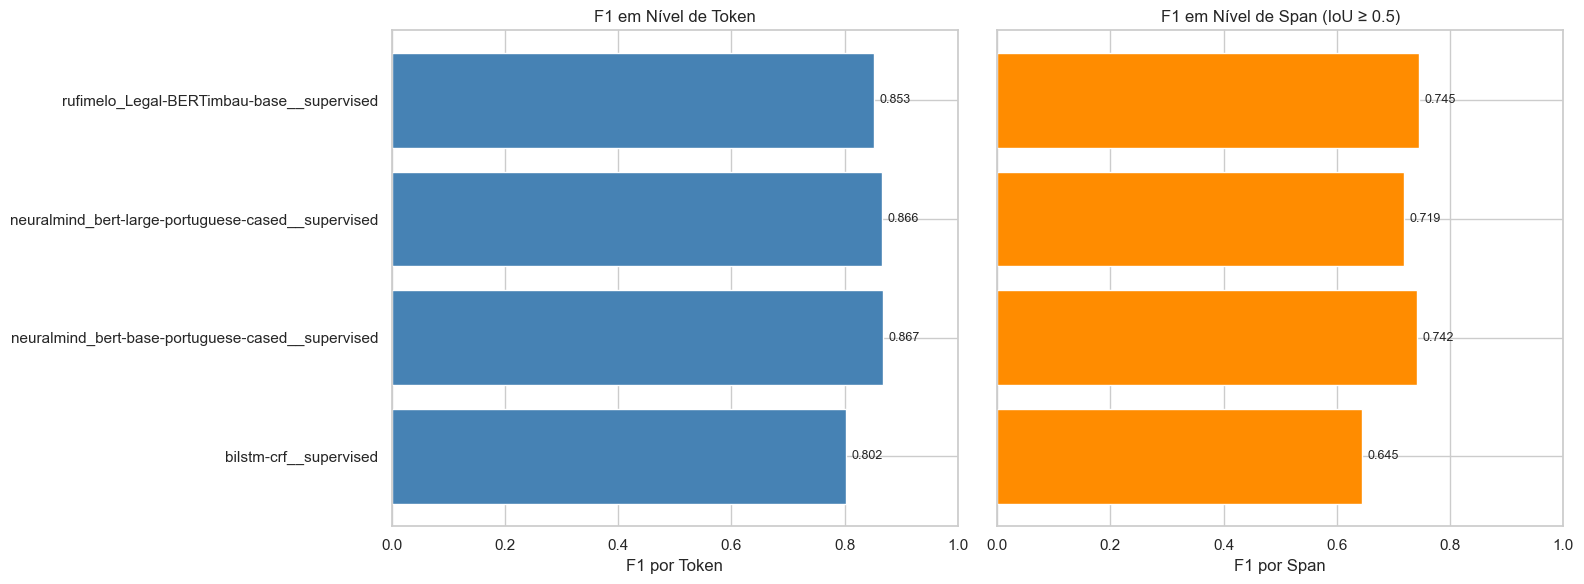

In [12]:
import os
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_metrics) * 0.4)), sharey=True)

order = df_metrics.index.tolist()

axes[0].barh(order, df_metrics['token_f1'], color='steelblue')
axes[0].set_xlabel('F1 por Token')
axes[0].set_title('F1 em Nível de Token')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_metrics['token_f1']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(order, df_metrics['span_f1'], color='darkorange')
axes[1].set_xlabel('F1 por Span')
axes[1].set_title('F1 em Nível de Span (IoU ≥ 0.5)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_metrics['span_f1']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/overall_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Entity Span F1 Heatmap

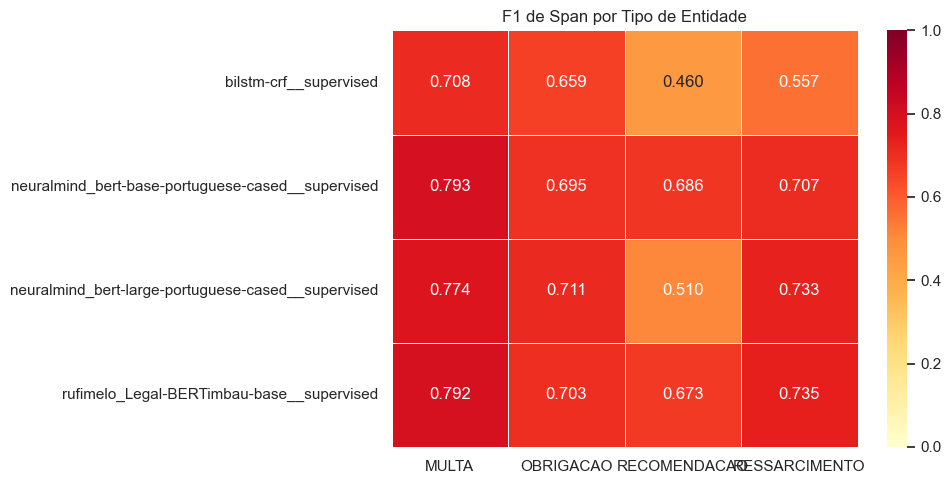

In [13]:
import os
entity_labels = ['MULTA', 'OBRIGACAO', 'RECOMENDACAO', 'RESSARCIMENTO']
f1_cols = [f'f1_{l}' for l in entity_labels if f'f1_{l}' in df_metrics.columns]

df_entity = df_metrics[f1_cols].copy()
df_entity.columns = [c.replace('f1_', '') for c in df_entity.columns]

fig, ax = plt.subplots(figsize=(10, max(5, len(df_entity) * 0.45)))
sns.heatmap(df_entity, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('F1 de Span por Tipo de Entidade')
ax.set_ylabel('')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/entity_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Strategy Comparison (grouped by strategy)

In [14]:
strategy_summary = df_metrics.groupby('strategy')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
strategy_summary.columns = ['_'.join(c) for c in strategy_summary.columns]
strategy_summary.sort_values('span_f1_mean', ascending=False, inplace=True)
display(strategy_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
strategy,,,,,,
supervised,0.847,0.0309,0.8674,0.7126,0.0466,0.745


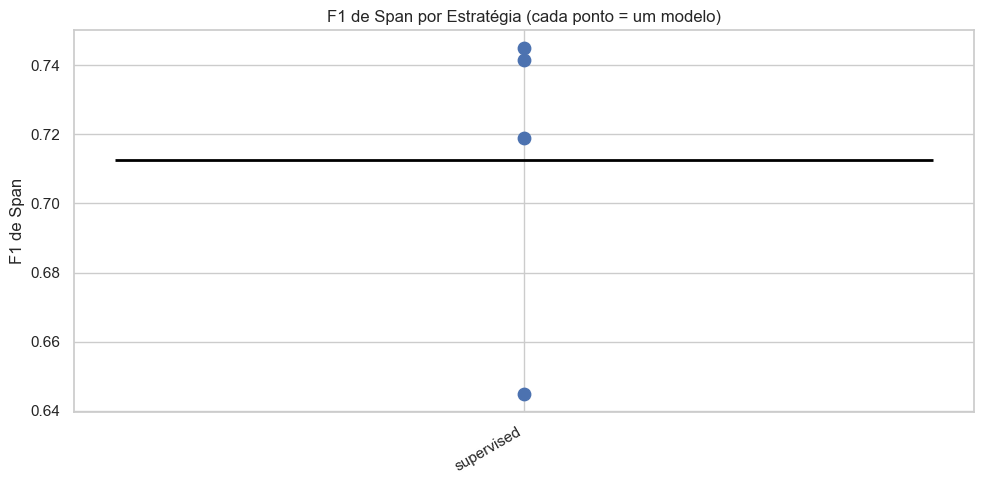

In [15]:
import os
fig, ax = plt.subplots(figsize=(10, 5))
strategies = df_metrics['strategy'].unique()
x = np.arange(len(strategies))

for i, strat in enumerate(sorted(strategies)):
    subset = df_metrics[df_metrics['strategy'] == strat]
    ax.scatter([i]*len(subset), subset['span_f1'], s=80, zorder=5, label=strat if i < 10 else '')
    ax.hlines(subset['span_f1'].mean(), i-0.2, i+0.2, colors='black', linewidth=2)

ax.set_xticks(range(len(sorted(strategies))))
ax.set_xticklabels(sorted(strategies), rotation=30, ha='right')
ax.set_ylabel('F1 de Span')
ax.set_title('F1 de Span por Estratégia (cada ponto = um modelo)')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison (grouped by model)

In [16]:
model_summary = df_metrics.groupby('model')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
model_summary.columns = ['_'.join(c) for c in model_summary.columns]
model_summary.sort_values('span_f1_mean', ascending=False, inplace=True)
display(model_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
model,,,,,,
rufimelo_Legal-BERTimbau-base,0.8525,NaN,0.8525,0.7450,NaN,0.7450
neuralmind_bert-base-portuguese-cased,0.8674,NaN,0.8674,0.7415,NaN,0.7415
neuralmind_bert-large-portuguese-cased,0.8665,NaN,0.8665,0.7189,NaN,0.7189
bilstm-crf,0.8018,NaN,0.8018,0.6448,NaN,0.6448


## 8. Precision vs Recall Scatter

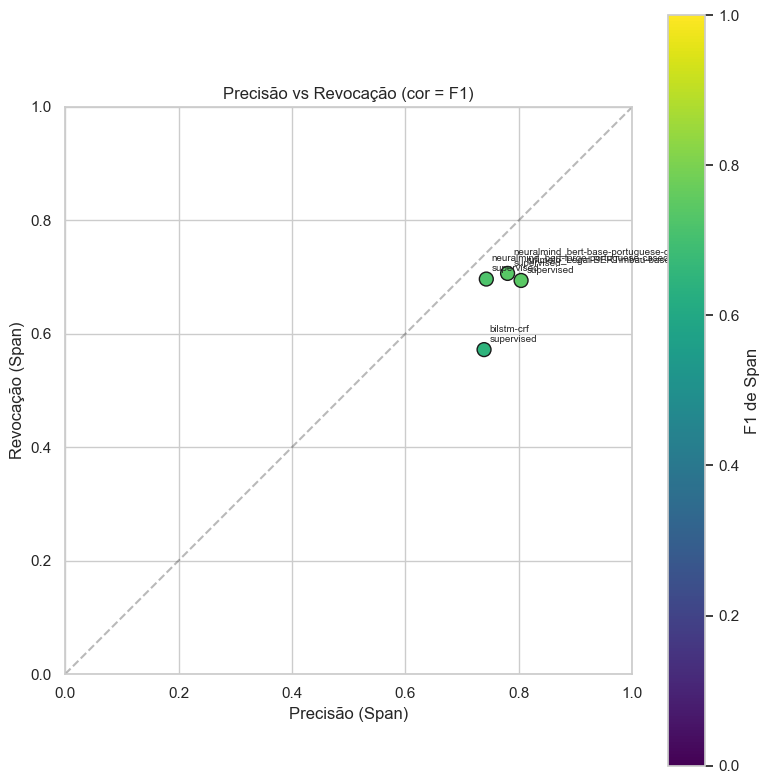

In [17]:
import os
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_metrics['span_precision'], df_metrics['span_recall'],
           s=100, c=df_metrics['span_f1'], cmap='viridis', edgecolors='k', vmin=0, vmax=1)

for idx, row in df_metrics.iterrows():
    label = idx.replace('__', '\n')
    ax.annotate(label, (row['span_precision'], row['span_recall']),
                fontsize=7, ha='left', va='bottom', xytext=(4, 4),
                textcoords='offset points')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precisão (Span)')
ax.set_ylabel('Revocação (Span)')
ax.set_title('Precisão vs Revocação (cor = F1)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], ax=ax, label='F1 de Span')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Supervised vs LLM-based

In [18]:
df_metrics['paradigm'] = df_metrics['strategy'].apply(
    lambda s: 'supervised' if s in ('supervised', 'test') else 'llm-prompting')

paradigm_summary = df_metrics.groupby('paradigm')[['token_f1', 'span_f1']].agg(['mean', 'max'])
paradigm_summary.columns = ['_'.join(c) for c in paradigm_summary.columns]
display(paradigm_summary.round(4))

,token_f1_mean,token_f1_max,span_f1_mean,span_f1_max
paradigm,,,,
supervised,0.847,0.8674,0.7126,0.745


## 10. Top-5 Experiments & Key Insights

In [19]:
print('=== TOP 5 by Span F1 ===')
display(df_metrics[['model', 'strategy', 'span_f1', 'token_f1']].head())

print('\n=== BEST per entity ===')
for label in entity_labels:
    col = f'f1_{label}'
    if col in df_metrics.columns:
        best_idx = df_metrics[col].idxmax()
        print(f'  {label}: {best_idx}  ({df_metrics.loc[best_idx, col]:.4f})')

print('\n=== BEST per strategy ===')
for strat in sorted(df_metrics['strategy'].unique()):
    subset = df_metrics[df_metrics['strategy'] == strat]
    best = subset['span_f1'].idxmax()
    print(f'  {strat}: {best}  (span_f1={subset.loc[best, "span_f1"]:.4f})')

=== TOP 5 by Span F1 ===


,model,strategy,span_f1,token_f1
experiment,,,,
bilstm-crf__supervised,bilstm-crf,supervised,0.644823,0.801826
neuralmind_bert-base-portuguese-cased__supervised,neuralmind_bert-base-portuguese-cased,supervised,0.741514,0.867359
neuralmind_bert-large-portuguese-cased__supervised,neuralmind_bert-large-portuguese-cased,supervised,0.718870,0.866474
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.744993,0.852500



=== BEST per entity ===
  MULTA: neuralmind_bert-base-portuguese-cased__supervised  (0.7933)
  OBRIGACAO: neuralmind_bert-large-portuguese-cased__supervised  (0.7113)
  RECOMENDACAO: neuralmind_bert-base-portuguese-cased__supervised  (0.6863)
  RESSARCIMENTO: rufimelo_Legal-BERTimbau-base__supervised  (0.7350)

=== BEST per strategy ===
  supervised: rufimelo_Legal-BERTimbau-base__supervised  (span_f1=0.7450)


## 11. Export Summary

In [20]:
df_metrics.to_csv('ner_results_summary.csv')
print('Saved ner_results_summary.csv')

Saved ner_results_summary.csv
